## PCMCI Algorithm


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 7
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable ozone has 6 link(s):
        (ozone -1): max_pval = 0.00000, |min_val| =  0.549
        (ozone -7): max_pval = 0.00039, |min_val| =  0.083
        (ozone -4): max_pval = 0.00151, |min_val| =  0.075
        (T2M -6): max_pval = 0.00195, |min_val| =  0.073
        (WS2M -1): max_pval = 0.00913, |min_val| =  0.061
        (RH2M -1): max_pval = 0.03113, |min_val| =  0.051

    Variable T2M has 7 link(s):
        (T2M -1): max_pval = 0.00000, |min_val| =  0.715
        (WS2M -1): max_pval = 0.00000, |min_val| =  0.251
        (RH2M -2): max_pval = 0.00000, |min_val| =  0.122
        (T2M -7): max_pval = 0.00006, |min_val| =  0.094
        (ozone -1): max_pval = 0.00017, |min_val| =  0.089
        (RH2M -3): max_pval = 0.00231, |min_val| =  0.072
  

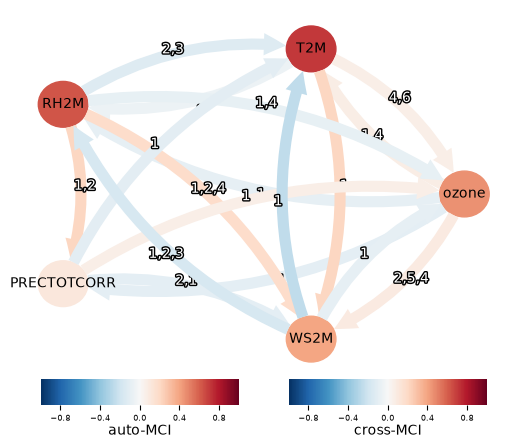

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tigramite.data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

# =========================
# 1. Load dataset
# =========================
DATA_PATH = "datasets/multipollutants_dallas_combined_with_Meteorology.csv"

df = pd.read_csv(DATA_PATH)

# =========================
# 2. Sort by date
# =========================
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# =========================
# 3. Select original measured variables only
# =========================
cols = [
    #"pm25",
    "ozone",
    "T2M",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
    # "WD2M",
    # "PS",
    # "pm_aqi",
    # "ozone_aqi"
]

data = df[cols].dropna().copy()

# =========================
# 4. Standardize data
# =========================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# =========================
# 5. Create Tigramite dataframe
# =========================
tigramite_df = pp.DataFrame(
    data_scaled,
    var_names=cols
)

# =========================
# 6. Run PCMCI
# =========================
parcorr = ParCorr(significance="analytic")

pcmci = PCMCI(
    dataframe=tigramite_df,
    cond_ind_test=parcorr,
    verbosity=1
)

tau_max = 7
alpha_level = 0.05

results = pcmci.run_pcmci(
    tau_min=1,
    tau_max=tau_max,
    pc_alpha=alpha_level
)

q_matrix = pcmci.get_corrected_pvalues(
    p_matrix=results["p_matrix"],
    tau_max=tau_max,
    fdr_method="fdr_bh"
)

graph = pcmci.get_graph_from_pmatrix(
    p_matrix=q_matrix,
    alpha_level=alpha_level,
    tau_min=1,
    tau_max=tau_max
)

# =========================
# 7. Print pollutant-focused causal links
# =========================
target_variables = ["ozone"]  # Focus on pollutant targets; can be extended to other variables if desired
#target_variables = cols
print("\nSignificant lagged causal links for pollutant targets:")

for target_name in target_variables:
    target_idx = cols.index(target_name)

    print(f"\nTarget variable: {target_name}")

    for source_idx, source_name in enumerate(cols):
        for tau in range(1, tau_max + 1):
            pval = q_matrix[source_idx, target_idx, tau]
            val = results["val_matrix"][source_idx, target_idx, tau]

            if pval < alpha_level:
                print(
                    f"{source_name}(t-{tau}) → {target_name}(t) | "
                    f"p={pval:.4f}, strength={val:.4f}"
                )

# =========================
# 8. Plot graph
# =========================
tp.plot_graph(
    val_matrix=results["val_matrix"],
    graph=graph,
    var_names=cols,
    link_colorbar_label="cross-MCI",
    node_colorbar_label="auto-MCI"
)

#plt.savefig("figures/pcmci_graph.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd
import os

def extract_pcmci_links(
    cols,
    graph,
    q_matrix,
    results,
    tau_max,
    target_variables="all",
    alpha_level=0.05,
    save_path=None,
    print_output=True
):

    # -------------------------
    # Select target variables
    # -------------------------
    if target_variables == "all":
        selected_targets = cols
    elif isinstance(target_variables, str):
        selected_targets = [target_variables]
    elif isinstance(target_variables, list):
        selected_targets = target_variables
    else:
        raise ValueError("target_variables must be 'all', a string, or a list of strings.")

    # -------------------------
    # Validate target names
    # -------------------------
    for target in selected_targets:
        if target not in cols:
            raise ValueError(f"Target '{target}' is not in cols. Available variables: {cols}")

    relationships = []

    # -------------------------
    # Extract causal links
    # -------------------------
    for target_name in selected_targets:
        target_idx = cols.index(target_name)

        for source_idx, source_name in enumerate(cols):
            for tau in range(1, tau_max + 1):

                link_type = graph[source_idx, target_idx, tau]

                if link_type != "":
                    pval = q_matrix[source_idx, target_idx, tau]
                    strength = results["val_matrix"][source_idx, target_idx, tau]

                    if pval < alpha_level:
                        relationships.append({
                            "Source": source_name,
                            "Target": target_name,
                            "Lag": tau,
                            "Relationship": f"{source_name}(t-{tau}) → {target_name}(t)",
                            "Link_Type": link_type,
                            "p_value": round(float(pval), 4),
                            "Strength": round(float(strength), 4),
                            "Link_Category": "Auto-MCI" if source_name == target_name else "Cross-MCI"
                        })

    relationships_df = pd.DataFrame(relationships)

    # -------------------------
    # Print output
    # -------------------------
    if print_output:
        if relationships_df.empty:
            print("No significant PCMCI links found.")
            print("Check target_variables, alpha_level, tau_max, or graph creation.")
        else:
            print("\nPCMCI causal links:\n")
            print(relationships_df.to_string(index=False))

    # -------------------------
    # Save output
    # -------------------------
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        relationships_df.to_csv(save_path, index=False)
        print(f"\nSaved to: {save_path}")

    return relationships_df


links_df = extract_pcmci_links(
    cols=cols,
    graph=graph,
    q_matrix=q_matrix,
    results=results,
    tau_max=tau_max,
    target_variables="all",
    alpha_level=alpha_level,
    #save_path="outputs/ozone_pcmci_links.csv"
)



PCMCI causal links:

     Source      Target  Lag                      Relationship Link_Type  p_value  Strength Link_Category
      ozone       ozone    1             ozone(t-1) → ozone(t)       -->   0.0000    0.4563      Auto-MCI
      ozone       ozone    4             ozone(t-4) → ozone(t)       -->   0.0058    0.0782      Auto-MCI
        T2M       ozone    4               T2M(t-4) → ozone(t)       -->   0.0249    0.0664     Cross-MCI
        T2M       ozone    6               T2M(t-6) → ozone(t)       -->   0.0459    0.0601     Cross-MCI
       RH2M       ozone    1              RH2M(t-1) → ozone(t)       -->   0.0023   -0.0843     Cross-MCI
       RH2M       ozone    4              RH2M(t-4) → ozone(t)       -->   0.0060    0.0775     Cross-MCI
PRECTOTCORR       ozone    1       PRECTOTCORR(t-1) → ozone(t)       -->   0.0251    0.0661     Cross-MCI
       WS2M       ozone    1              WS2M(t-1) → ozone(t)       -->   0.0005   -0.0936     Cross-MCI
      ozone         T2M 

/tmp/ipykernel_3330992/1125443317.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


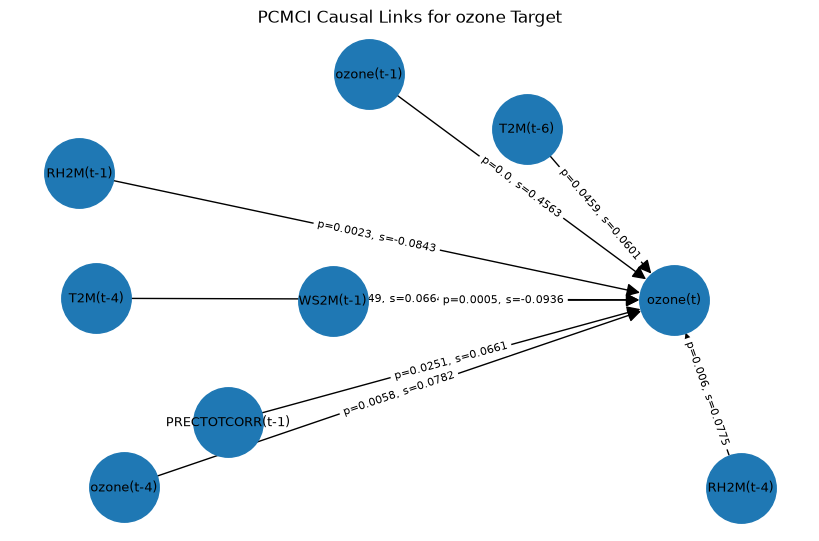

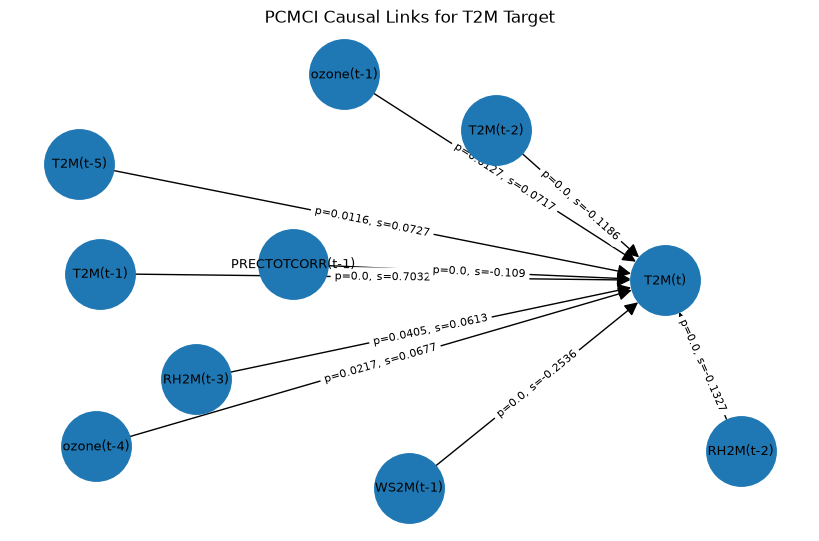

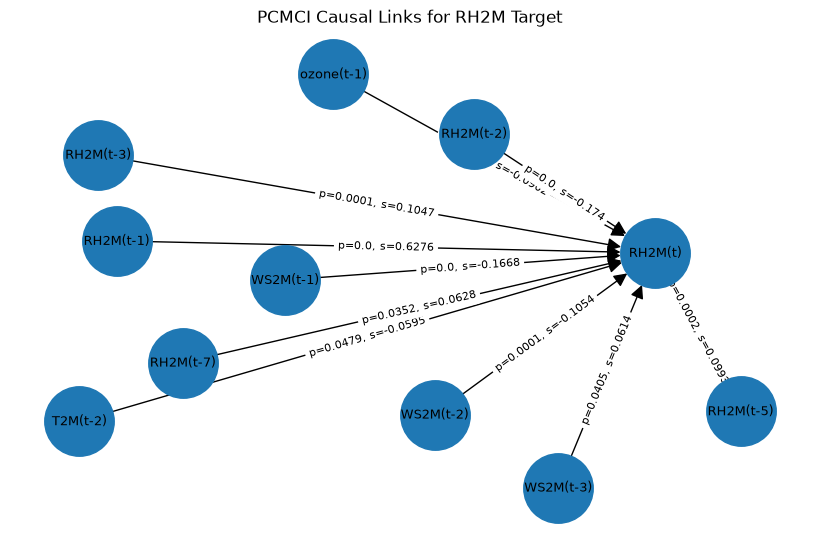

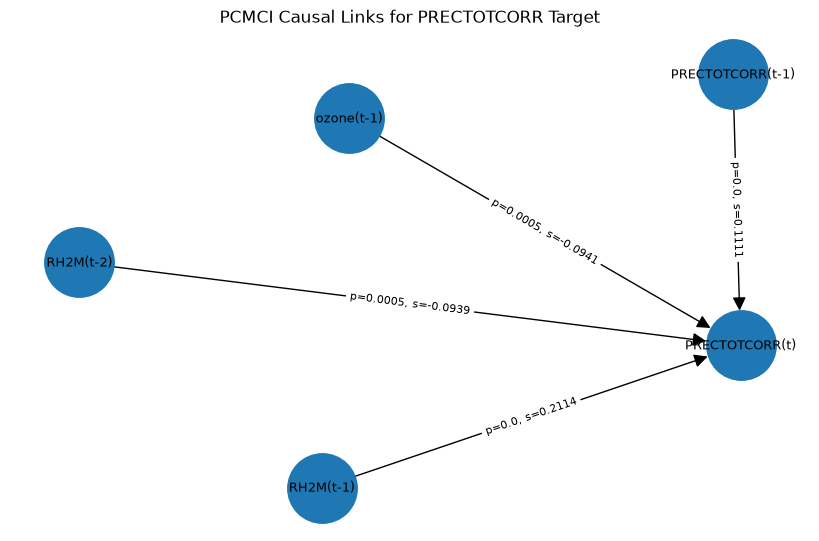

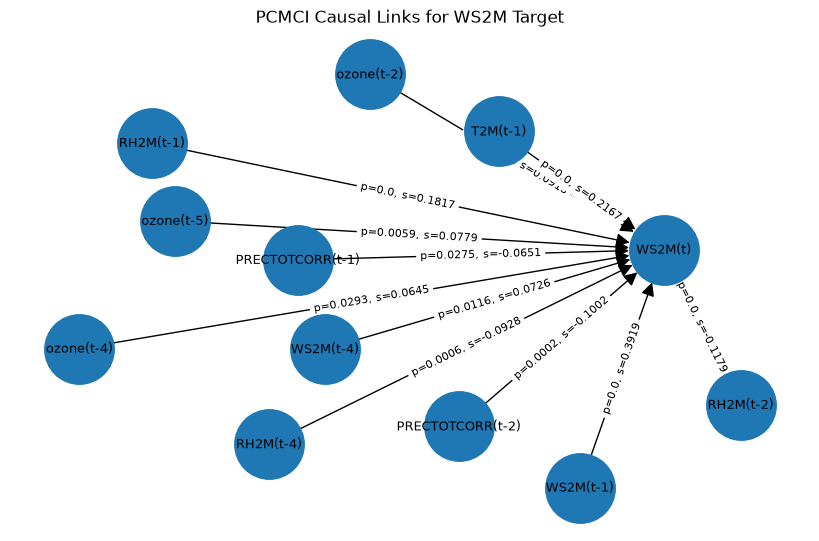

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import os

def plot_pcmci_target_graph(
    cols,
    graph,
    q_matrix,
    results,
    tau_max,
    target_variables="ozone",
    alpha_level=0.05,
    save_path=None,
    figsize=(8, 5)
):
    #"pm25"              -> one target
    #["pm25", "ozone"]   -> multiple targets
    #"all"               -> all variables as targets

    # -------------------------
    # Select target variables
    # -------------------------
    if target_variables == "all":
        selected_targets = cols
    elif isinstance(target_variables, str):
        selected_targets = [target_variables]
    elif isinstance(target_variables, list):
        selected_targets = target_variables
    else:
        raise ValueError("target_variables must be 'all', a string, or a list.")

    # -------------------------
    # Validate target names
    # -------------------------
    for target in selected_targets:
        if target not in cols:
            raise ValueError(f"Target '{target}' is not in cols. Available variables: {cols}")

    # -------------------------
    # Plot one graph per target
    # -------------------------
    for target_name in selected_targets:
        target_idx = cols.index(target_name)

        G_target = nx.DiGraph()

        for source_idx, source_name in enumerate(cols):
            for tau in range(1, tau_max + 1):

                link_type = graph[source_idx, target_idx, tau]

                if link_type != "":
                    pval = q_matrix[source_idx, target_idx, tau]
                    strength = results["val_matrix"][source_idx, target_idx, tau]

                    if pval < alpha_level:
                        source_label = f"{source_name}(t-{tau})"
                        target_label = f"{target_name}(t)"

                        G_target.add_edge(
                            source_label,
                            target_label,
                            p=round(float(pval), 4),
                            strength=round(float(strength), 4)
                        )

        if G_target.number_of_edges() == 0:
            print(f"No significant links found for target: {target_name}")
            continue

        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G_target, seed=42)

        nx.draw(
            G_target,
            pos,
            with_labels=True,
            node_size=2500,
            font_size=9,
            arrows=True,
            arrowsize=20
        )

        edge_labels = {
            (u, v): f"p={d['p']}, s={d['strength']}"
            for u, v, d in G_target.edges(data=True)
        }

        nx.draw_networkx_edge_labels(
            G_target,
            pos,
            edge_labels=edge_labels,
            font_size=8
        )

        plt.title(f"PCMCI Causal Links for {target_name} Target")
        plt.axis("off")
        plt.tight_layout()

        if save_path is not None:
            os.makedirs(save_path, exist_ok=True)
            file_path = os.path.join(save_path, f"pcmci_{target_name}_target_graph.png")
            plt.savefig(file_path, dpi=300, bbox_inches="tight")
            print(f"Saved graph: {file_path}")

        plt.show()

plot_pcmci_target_graph(
    cols=cols,
    graph=graph,
    q_matrix=q_matrix,
    results=results,
    tau_max=tau_max,
    target_variables="all",
    alpha_level=alpha_level,
    #save_path="figures"
)

/tmp/ipykernel_3330992/1449071236.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


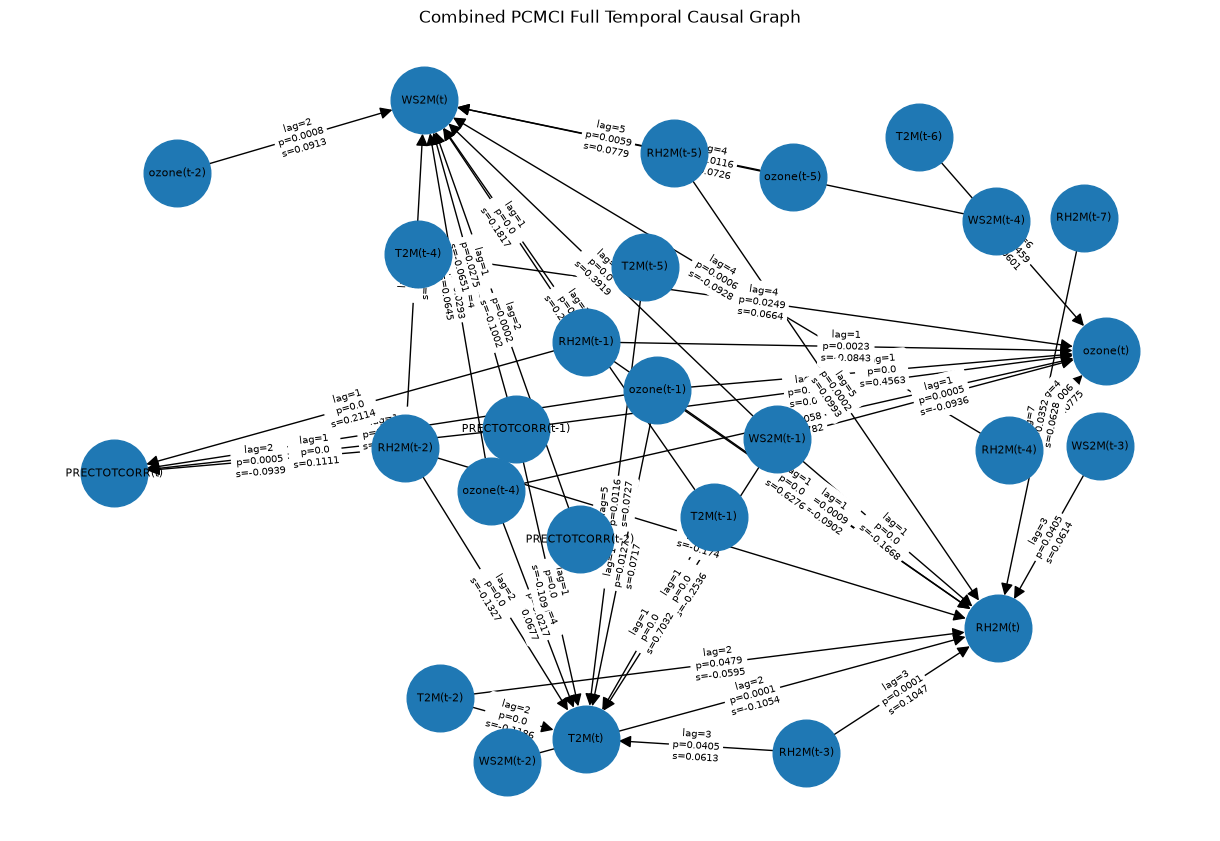

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import os

def plot_pcmci_combined_graph(
    cols,
    graph,
    q_matrix,
    results,
    tau_max,
    target_variables="all",
    alpha_level=0.05,
    save_path=None,
    figsize=(12, 8)
):
    # Select target variables
    if target_variables == "all":
        selected_targets = cols
    elif isinstance(target_variables, str):
        selected_targets = [target_variables]
    elif isinstance(target_variables, list):
        selected_targets = target_variables
    else:
        raise ValueError("target_variables must be 'all', a string, or a list.")

    # Validate targets
    for target in selected_targets:
        if target not in cols:
            raise ValueError(f"Target '{target}' is not in cols. Available variables: {cols}")

    G = nx.DiGraph()

    for target_name in selected_targets:
        target_idx = cols.index(target_name)

        for source_idx, source_name in enumerate(cols):
            for tau in range(1, tau_max + 1):

                link_type = graph[source_idx, target_idx, tau]

                if link_type != "":
                    pval = q_matrix[source_idx, target_idx, tau]
                    strength = results["val_matrix"][source_idx, target_idx, tau]

                    if pval < alpha_level:
                        source_node = f"{source_name}(t-{tau})"
                        target_node = f"{target_name}(t)"

                        G.add_edge(
                            source_node,
                            target_node,
                            p=round(float(pval), 4),
                            strength=round(float(strength), 4),
                            lag=tau
                        )

    if G.number_of_edges() == 0:
        print("No significant links found.")
        return G

    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, seed=42, k=1.2)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2300,
        font_size=8,
        arrows=True,
        arrowsize=18
    )

    edge_labels = {
        (u, v): f"lag={d['lag']}\np={d['p']}\ns={d['strength']}"
        for u, v, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )

    if target_variables == "all":
        title = "Combined PCMCI Full Temporal Causal Graph"
    else:
        title = f"Combined PCMCI Graph for Targets: {selected_targets}"

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        file_path = os.path.join(save_path, "combined_pcmci_temporal_graph.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph: {file_path}")

    plt.show()

    return G

G_combined = plot_pcmci_combined_graph(
    cols=cols,
    graph=graph,
    q_matrix=q_matrix,
    results=results,
    tau_max=tau_max,
    target_variables="all",
    alpha_level=alpha_level,
    #save_path="figures"
)